## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_EL = 'θεσσαλιας'

In [4]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_Biweekly_2022_filled.csv', encoding=enc)


In [5]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,αγιας,θεσσαλιας,22.63715,39.66477,2022-01-01,2022,1,2022-01-30,39.662866,22.635299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-01-01,39.662866,22.635299,14317.0,13912.0,39.662866,22.635299,14083.318182,13651.789474,14359.071429,13768.416667,14456.400000,13662.357143,15045.882353,14085.125000,2022-01-01,39.650181,22.650104,0.000000,2021-12-25,2021-12-18,2022-12-16,2022-12-16,0.000000,0.000000
1,αγιας,θεσσαλιας,22.63715,39.66477,2022-01-16,2022,1,2022-01-15,39.662866,22.635299,0.323408,0.207092,-0.223242,-0.207092,0.293262,0.160975,-0.210457,-0.160975,0.059568,0.085228,0.055314,0.085228,2022-01-16,39.662866,22.635299,13930.0,13693.0,39.662866,22.635299,14083.318182,13651.789474,14359.071429,13768.416667,14456.400000,13662.357143,15045.882353,14085.125000,2022-01-16,39.650181,22.650104,218.887877,2022-01-09,2022-01-02,2022-01-09,2022-01-02,217.874235,218.887877
2,αγιας,θεσσαλιας,22.70702,39.75460,2022-01-01,2022,1,2022-01-30,39.752697,22.707165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-01-01,39.752697,22.707165,NaN,13958.0,39.752697,22.707165,13830.777778,13764.000000,14072.545455,13723.625000,13979.375000,13740.800000,14703.857143,13946.133333,2022-01-01,39.750182,22.750104,0.000000,2021-12-25,2021-12-18,2022-12-16,2022-12-16,0.000000,0.000000
3,αγιας,θεσσαλιας,22.70702,39.75460,2022-01-16,2022,1,2022-01-15,39.752697,22.707165,NaN,NaN,NaN,NaN,0.029346,0.442019,-0.007528,-0.442019,0.000000,0.000000,0.000000,0.000000,2022-01-16,39.752697,22.707165,13697.0,13600.0,39.752697,22.707165,13830.777778,13764.000000,14072.545455,13723.625000,13979.375000,13740.800000,14703.857143,13946.133333,2022-01-16,39.750182,22.750104,239.477200,2022-01-09,2022-01-02,2022-01-09,2022-01-02,238.043966,239.477200
4,αγιας,θεσσαλιας,22.73031,39.79054,2022-01-01,2022,1,2022-01-30,39.788630,22.729622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-01-01,39.788630,22.729622,NaN,13880.0,39.788630,22.729622,13734.000000,13861.400000,13833.888889,13762.250000,13785.444444,13823.000000,14567.583333,13906.500000,2022-01-01,39.750182,22.750104,0.000000,2021-12-25,2021-12-18,2022-12-16,2022-12-16,0.000000,0.000000


In [6]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [7]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [8]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [9]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας,θεσσαλιας,22.63715,39.66477,2022-01-01,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14317.0,13912.0,14083.318182,13651.789474,14359.071429,13768.416667,14456.400000,13662.357143,15045.882353,14085.125000,0.000000,0.000000,0.000000
1,αγιας,θεσσαλιας,22.63715,39.66477,2022-01-16,2022,1,0.323408,0.207092,-0.223242,-0.207092,0.293262,0.160975,-0.210457,-0.160975,0.059568,0.085228,0.055314,0.085228,13930.0,13693.0,14083.318182,13651.789474,14359.071429,13768.416667,14456.400000,13662.357143,15045.882353,14085.125000,218.887877,217.874235,218.887877
2,αγιας,θεσσαλιας,22.70702,39.75460,2022-01-01,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13958.0,13830.777778,13764.000000,14072.545455,13723.625000,13979.375000,13740.800000,14703.857143,13946.133333,0.000000,0.000000,0.000000
3,αγιας,θεσσαλιας,22.70702,39.75460,2022-01-16,2022,1,NaN,NaN,NaN,NaN,0.029346,0.442019,-0.007528,-0.442019,0.000000,0.000000,0.000000,0.000000,13697.0,13600.0,13830.777778,13764.000000,14072.545455,13723.625000,13979.375000,13740.800000,14703.857143,13946.133333,239.477200,238.043966,239.477200
4,αγιας,θεσσαλιας,22.73031,39.79054,2022-01-01,2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13880.0,13734.000000,13861.400000,13833.888889,13762.250000,13785.444444,13823.000000,14567.583333,13906.500000,0.000000,0.000000,0.000000


In [10]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2022-01-01,αγιας,θεσσαλιας,22.750267,39.710970,2022.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14281.000000,14035.142857,13946.530227,13768.484943,14128.912163,13770.359127,14179.946149,13771.168878,14711.620173,14042.292792,0.000000,0.000000,0.000000
1,2022-01-01,αλμυρου,θεσσαλιας,22.692366,39.136391,2022.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14276.375000,14013.555556,14088.341244,13747.596594,14238.749179,13798.552357,14311.203612,13789.415103,14789.425744,14140.293954,0.000138,0.000138,0.000138
2,2022-01-01,αλοννησου,θεσσαλιας,24.073790,39.328960,2022.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14198.000000,14205.400000,14069.857143,14291.307692,14036.666667,14283.900000,14011.818182,14607.631579,14277.666667,0.453699,0.453699,0.453699
3,2022-01-01,αργιθεας,θεσσαλιας,21.430513,39.221380,2022.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14173.000000,13969.333333,13813.000000,13614.968219,13999.987179,13683.657576,13976.834832,13600.170655,14591.410256,13998.950794,0.455287,0.455287,0.455287
4,2022-01-01,βολου,θεσσαλιας,22.883800,39.351977,2022.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14046.333333,14105.000000,14171.453199,13762.569853,14326.441392,13838.500000,14388.153691,13777.372727,14890.170868,14143.785577,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,2022-12-16,τεμπων,θεσσαλιας,22.553160,39.852112,2022.0,12.0,0.477759,0.152211,-0.389123,-0.152211,0.487939,0.144348,-0.411254,-0.144348,0.051411,0.071228,0.041737,0.071228,14257.000000,14170.400000,13888.346715,13683.892353,14095.155711,13737.560404,14115.457669,13679.157980,14702.253277,14067.814982,1017.411256,8.098654,9.122005
596,2022-12-16,τρικκαιων,θεσσαλιας,21.797560,39.635058,2022.0,12.0,0.285819,0.004022,-0.221454,-0.004022,0.294226,0.022743,-0.223941,-0.022743,0.044244,0.050393,0.042606,0.050393,14352.200000,14113.200000,14130.884762,13666.107353,14346.223310,13730.069697,14418.705195,13728.572121,14922.437182,14123.490245,1050.398275,29.966226,30.347858
597,2022-12-16,τυρναβου,θεσσαλιας,22.343000,39.828472,2022.0,12.0,0.453907,0.075541,-0.392130,-0.075541,0.392833,0.053335,-0.334736,-0.053335,0.046209,0.063514,0.034367,0.063514,14344.750000,14051.500000,14077.990981,13625.109743,14283.670940,13724.536859,14387.072650,13681.028283,14882.338796,14095.495475,1029.457235,12.195694,12.909679
598,2022-12-16,φαρκαδονας,θεσσαλιας,22.020557,39.603750,2022.0,12.0,0.212071,-0.081474,-0.177903,0.081474,0.255763,-0.015408,-0.202076,0.015408,0.060588,0.067927,0.053202,0.067927,14396.666667,14040.333333,14094.681579,13694.162037,14337.983516,13768.886364,14429.993651,13768.516162,14981.523611,14174.105392,1054.837157,46.772979,47.195847


In [11]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [12]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [13]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [14]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [15]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [16]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'THESSALY'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [17]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [18]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

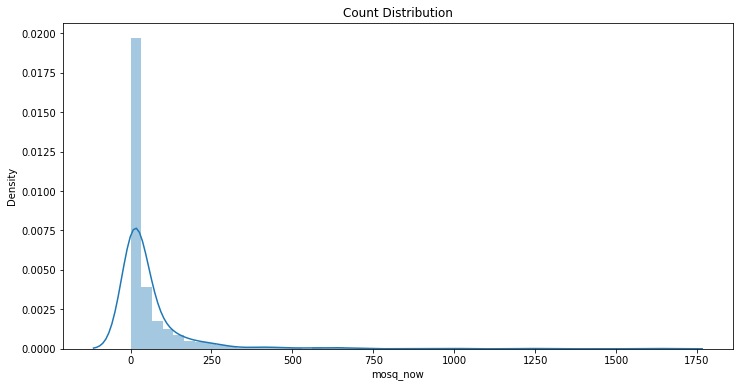

In [19]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [20]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

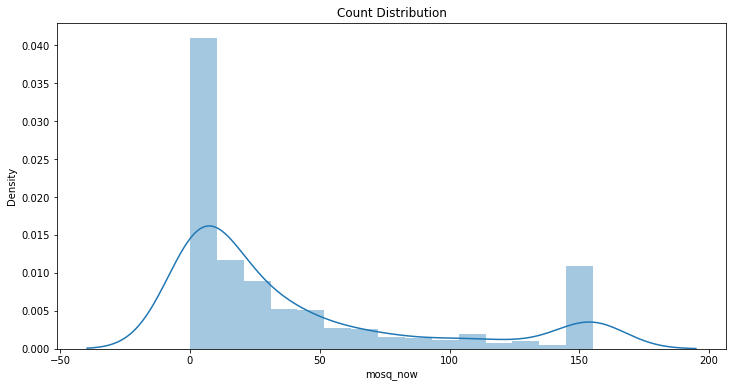

In [21]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

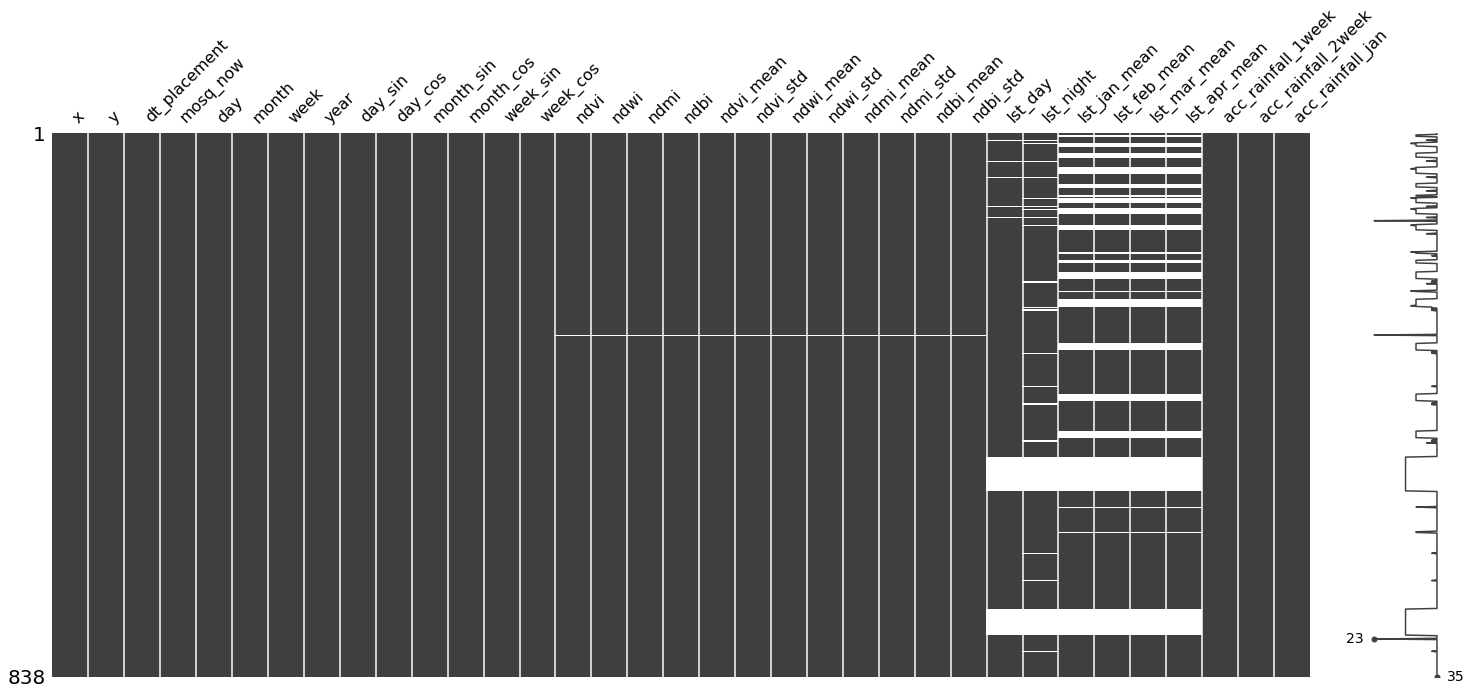

In [22]:
missingno.matrix(mosquito_data_nuts2)

In [23]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [24]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

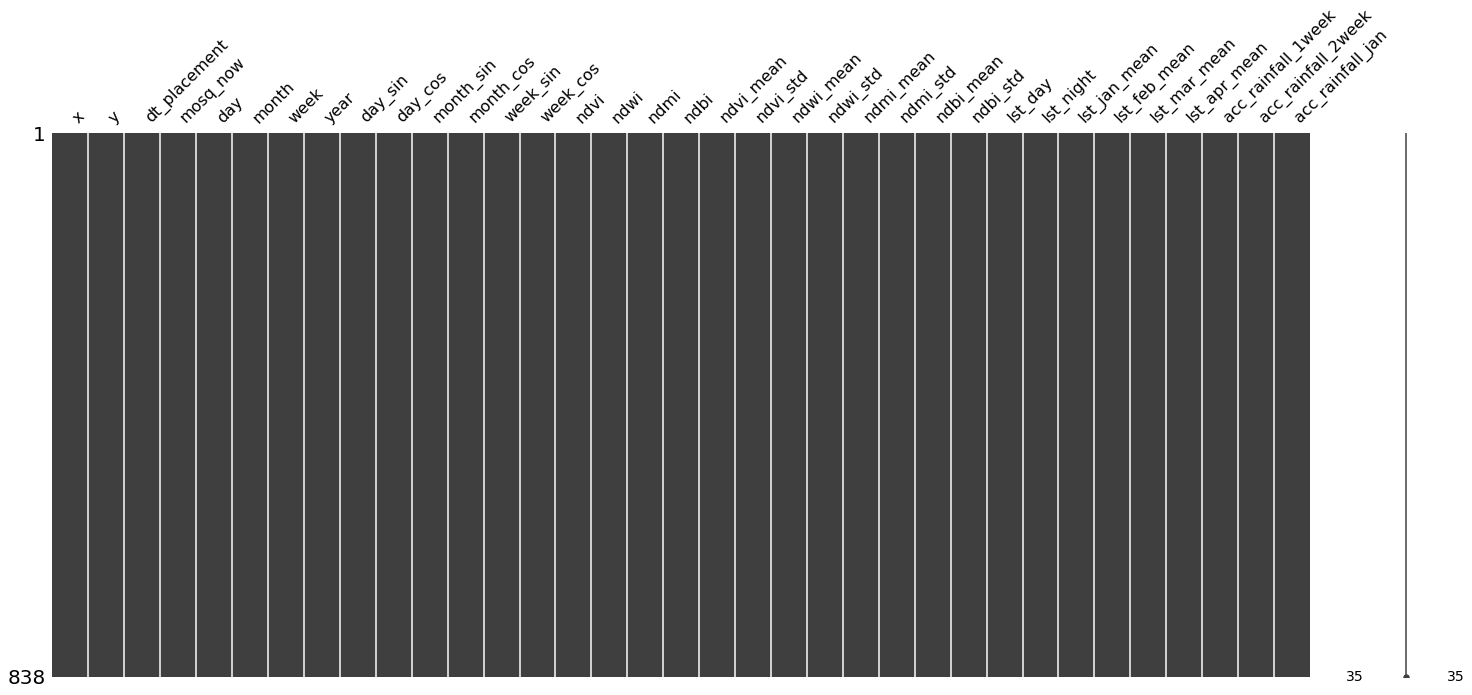

In [25]:
missingno.matrix(mosquito_data_nuts2)

In [26]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [27]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.   16.5 155.3]


In [28]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 42.74083 | Val Loss: 27.19290 | Train Acc: 4.518| Val Acc: 2.843
Epoch 002: | Train Loss: 38.74320 | Val Loss: 26.39427 | Train Acc: 3.956| Val Acc: 2.817
Epoch 003: | Train Loss: 36.69901 | Val Loss: 27.48983 | Train Acc: 3.526| Val Acc: 3.253
Epoch 004: | Train Loss: 35.24920 | Val Loss: 27.85307 | Train Acc: 3.170| Val Acc: 3.342
Epoch 005: | Train Loss: 34.20468 | Val Loss: 27.48284 | Train Acc: 2.977| Val Acc: 3.174
Epoch 006: | Train Loss: 33.92665 | Val Loss: 26.42086 | Train Acc: 2.819| Val Acc: 3.073
Epoch 007: | Train Loss: 34.11702 | Val Loss: 24.06737 | Train Acc: 2.781| Val Acc: 2.503
Epoch 008: | Train Loss: 33.31432 | Val Loss: 23.25718 | Train Acc: 2.740| Val Acc: 2.091
Epoch 009: | Train Loss: 32.89629 | Val Loss: 23.42146 | Train Acc: 2.724| Val Acc: 1.874
Epoch 010: | Train Loss: 33.17614 | Val Loss: 23.22164 | Train Acc: 2.766| Val Acc: 1.806
Epoch 011: | Train Loss: 32.69262 | Val Loss: 23.24044 | Train Acc: 2.716| Val Acc: 1.791
Epoch 012:

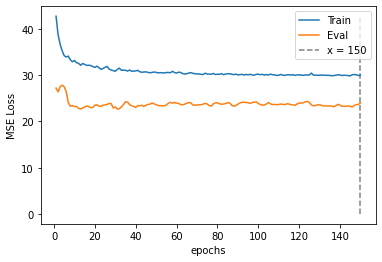

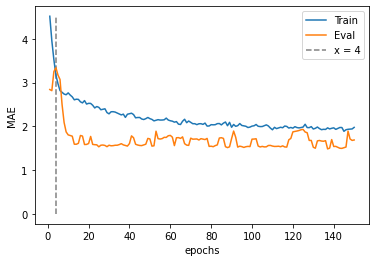

In [29]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [30]:
metrics(train, test, threshold=30)

MAE on train set:  21.216086752104893
min prediction: 1
max prediction: 235

MAE on test set:  25.01603082358855
Error ⩽ 30: 70.99 %
min prediction: 1
max prediction: 220


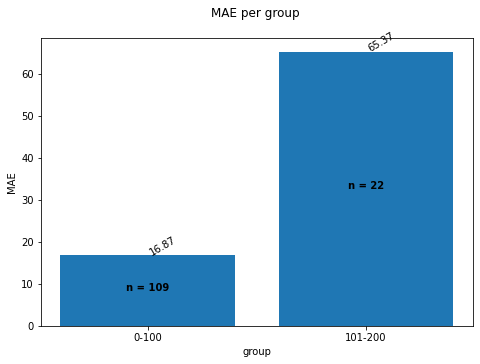

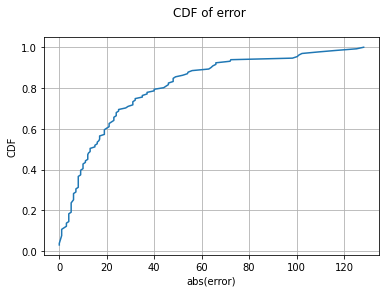

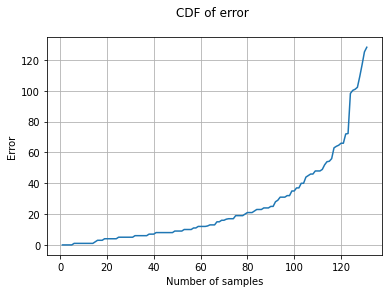

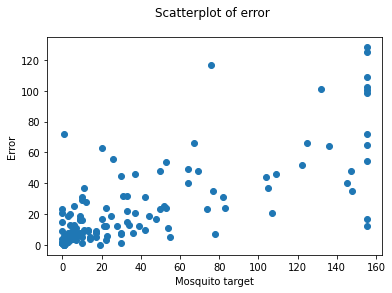

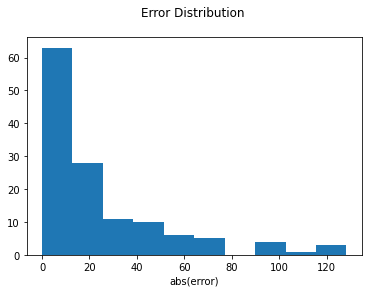

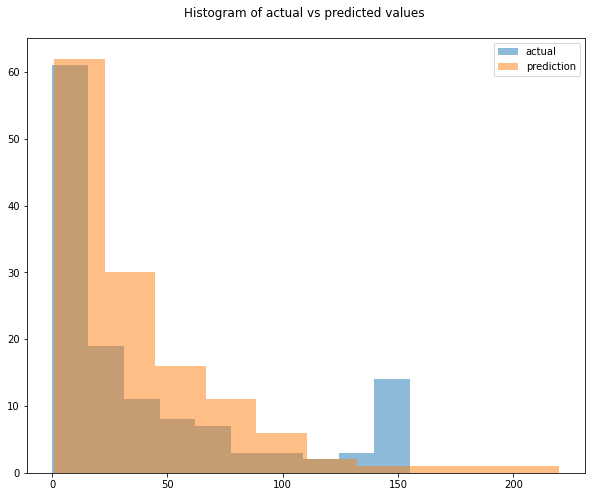

In [31]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 33.90292 | Val Loss: 0.29809 | Train Acc: 2.412| Val Acc: 0.955
Epoch 002: | Train Loss: 33.23939 | Val Loss: 0.16826 | Train Acc: 2.298| Val Acc: 0.045
Epoch 003: | Train Loss: 33.02969 | Val Loss: 0.07179 | Train Acc: 2.170| Val Acc: 0.045
Epoch 004: | Train Loss: 33.32074 | Val Loss: 0.56766 | Train Acc: 2.198| Val Acc: 1.045
Epoch 005: | Train Loss: 32.84883 | Val Loss: 0.52701 | Train Acc: 2.200| Val Acc: 1.045
Epoch 006: | Train Loss: 32.72758 | Val Loss: 0.24725 | Train Acc: 2.232| Val Acc: 0.045
Epoch 007: | Train Loss: 32.59234 | Val Loss: 0.09470 | Train Acc: 2.215| Val Acc: 0.045
Epoch 008: | Train Loss: 32.53846 | Val Loss: 0.10736 | Train Acc: 2.170| Val Acc: 0.045
Epoch 009: | Train Loss: 32.48964 | Val Loss: 0.15817 | Train Acc: 2.189| Val Acc: 0.045
Epoch 010: | Train Loss: 32.45790 | Val Loss: 0.25547 | Train Acc: 2.142| Val Acc: 0.045
Epoch 011: | Train Loss: 32.27015 | Val Loss: 0.36579 | Train Acc: 2.142| Val Acc: 1.045
Epoch 012: | Train Lo

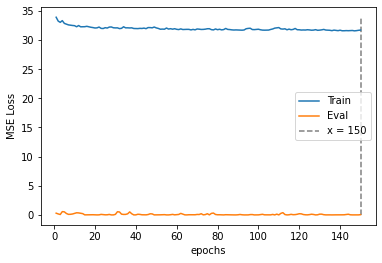

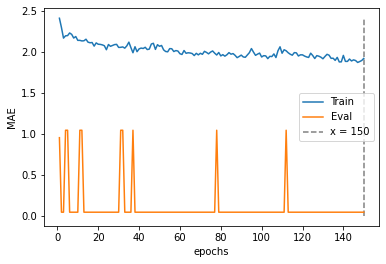

In [32]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [33]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [34]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [35]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [36]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [37]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [38]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

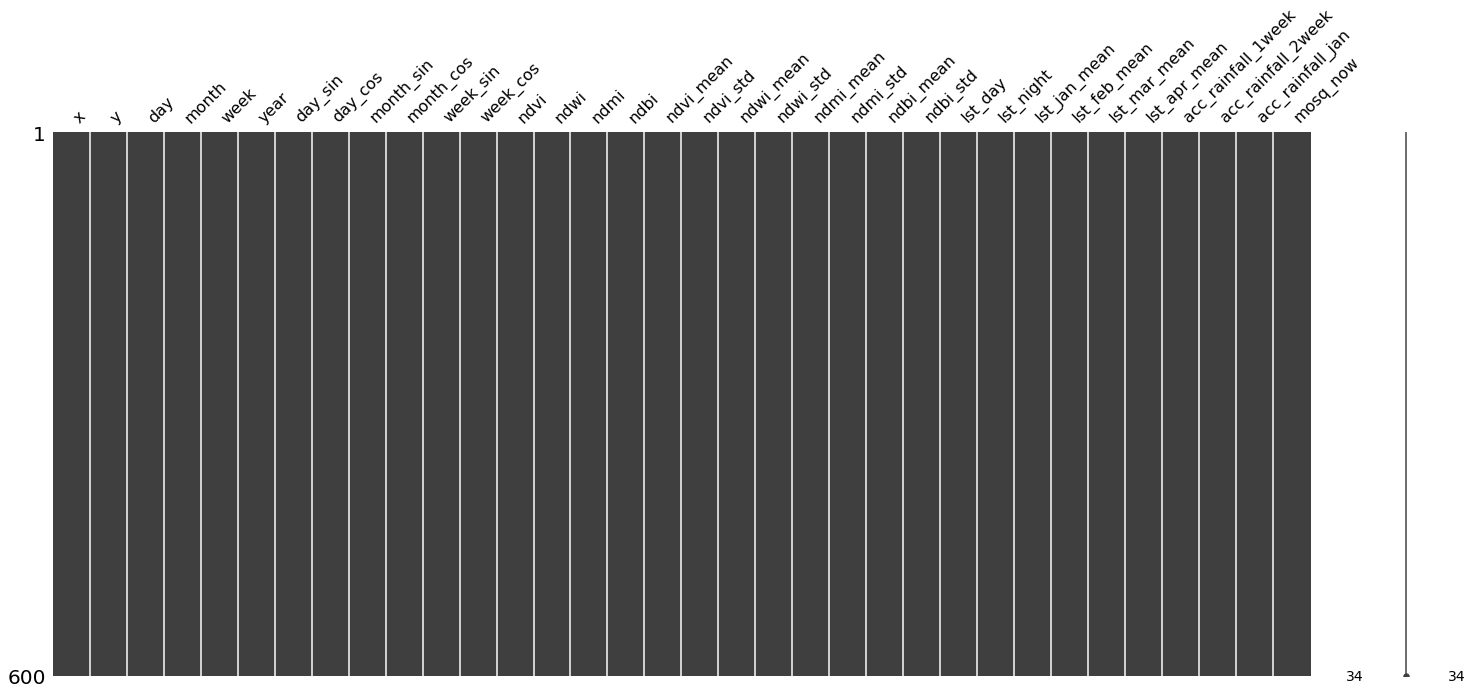

In [39]:
missingno.matrix(dataset_mamoth)

In [40]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [41]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [42]:
predictions = give_predictions(model, dataset_mamoth)

In [43]:
mosqutio_predictions['mosq_pred'] = predictions

In [44]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.750267,39.710970,2022-01-01,6
1,22.692366,39.136391,2022-01-01,5
2,24.073790,39.328960,2022-01-01,2
3,21.430513,39.221380,2022-01-01,12
4,22.883800,39.351977,2022-01-01,4
...,...,...,...,...
595,22.553160,39.852112,2022-12-16,41
596,21.797560,39.635058,2022-12-16,56
597,22.343000,39.828472,2022-12-16,58
598,22.020557,39.603750,2022-12-16,59


In [45]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2022.csv', index = False)